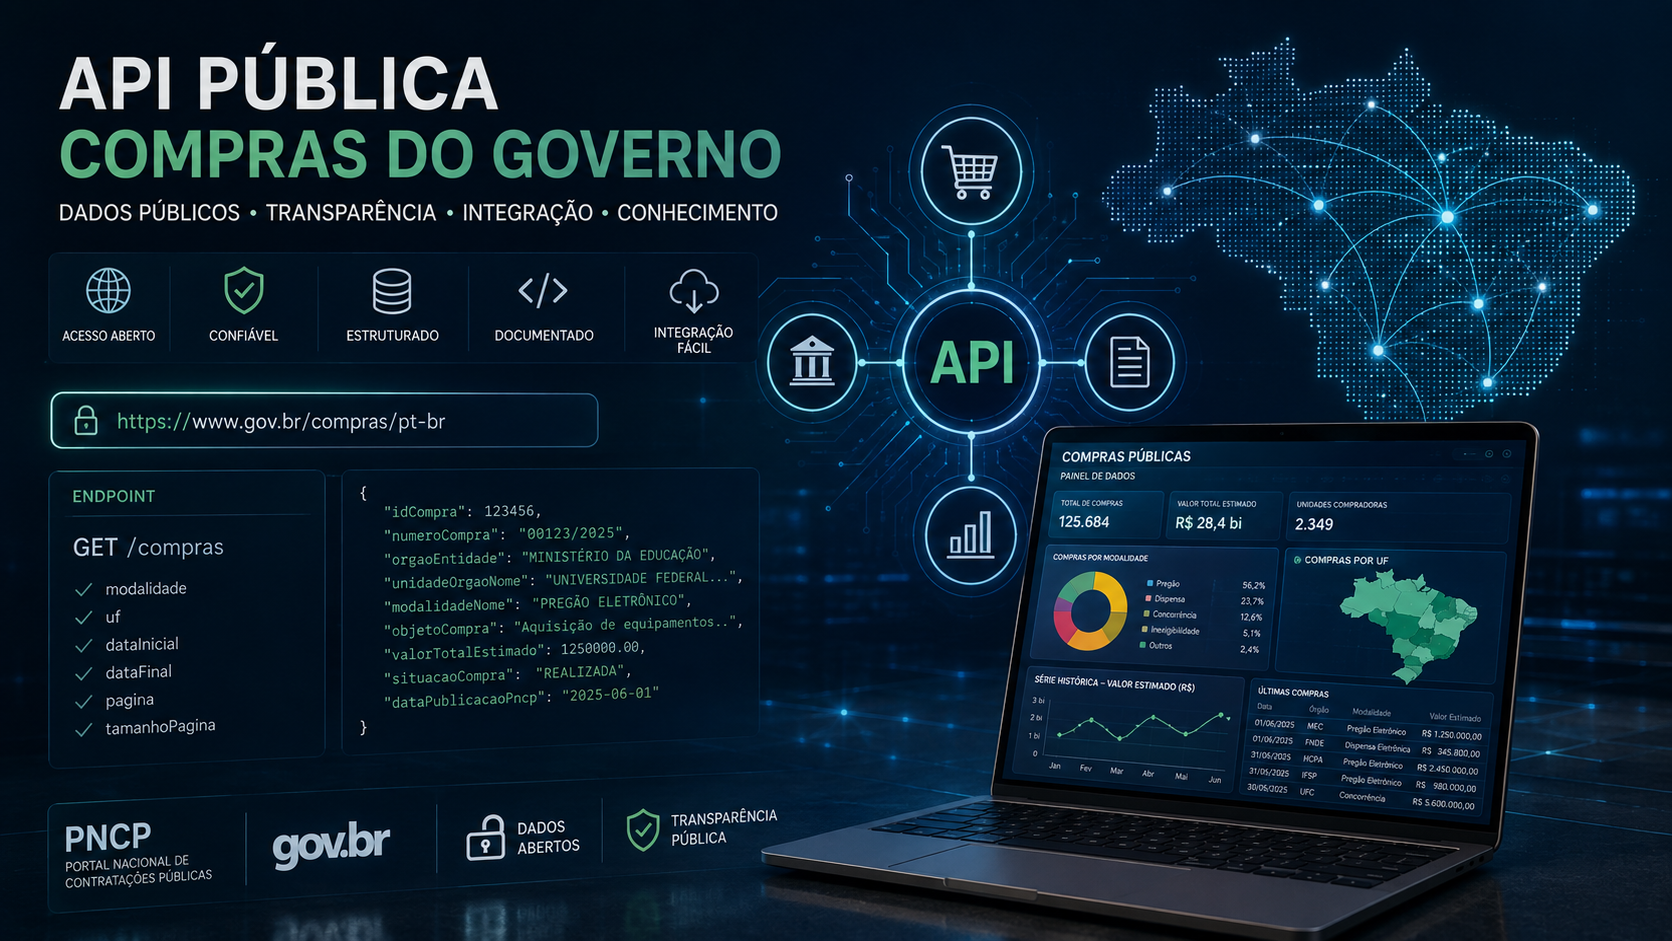

# Consumo da API de Compras Governamentais

Nesta atividade, utilizaremos a **API pública de Dados Abertos do Compras.gov.br** para consultar contratações governamentais e organizar os resultados em `DataFrames`.

Documentação oficial:

- Swagger: https://dadosabertos.compras.gov.br/swagger-ui/index.html
- Portal de dados abertos: https://dados.gov.br/dados/conjuntos-dados/compras-publicas-do-governo-federal

A atividade está organizada em duas partes:

1. **prática guiada**, para compreender o consumo da API;
2. **desafio investigativo em duplas**, voltado à exploração dos dados, identificação de padrões e geração de evidências com potencial para produzir novos conhecimentos.

> Os dados são obtidos diretamente de uma API externa. Portanto, disponibilidade, tempo de resposta, quantidade de registros e estrutura de alguns campos podem sofrer alterações ao longo do tempo.


## 1. Objetivos da aula

Ao final da atividade, espera-se que seja possível:

- interpretar a documentação de uma API pública;
- construir requisições HTTP com `requests`;
- utilizar parâmetros de consulta;
- verificar códigos de status HTTP;
- interpretar respostas JSON;
- transformar dados JSON em `DataFrame`;
- tratar paginação;
- realizar análises exploratórias iniciais;
- formular perguntas de pesquisa a partir de dados públicos reais.


## 2. Bibliotecas

Utilizaremos principalmente:

- `requests` para realizar as requisições HTTP;
- `pandas` para organizar e analisar os dados;
- `matplotlib` para visualizações simples.


In [ ]:
#%pip install requests pandas matplotlib -q

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 3. Conhecendo a API

A API do Compras.gov.br possui diferentes módulos.

Alguns exemplos:

```text
Catálogo de materiais
Catálogo de serviços
Pesquisa de preços
Contratações
Atas de Registro de Preços
Contratos
Fornecedores
```

Nesta prática utilizaremos principalmente o endpoint:

```text
GET /modulo-contratacoes/1_consultarContratacoes_PNCP_14133
```

Esse serviço consulta contratações realizadas no contexto da Lei nº 14.133/2021. Esta Lei estabelece normas gerais de licitação e contratação para as Administrações Públicas diretas, autárquicas e fundacionais da União, dos Estados, do Distrito Federal e dos Municípios

A URL base será:


In [ ]:
BASE_URL = "https://dadosabertos.compras.gov.br"

ENDPOINT_CONTRATACOES = "/modulo-contratacoes/1_consultarContratacoes_PNCP_14133"

url = BASE_URL + ENDPOINT_CONTRATACOES

print(url)

## 4. Parâmetros da consulta

O endpoint permite utilizar parâmetros para restringir a consulta.

Nesta atividade utilizaremos:

- `pagina`: página desejada;
- `tamanhoPagina`: número de registros por página;
- `dataPublicacaoPncpInicial`: data inicial;
- `dataPublicacaoPncpFinal`: data final;
- `codigoModalidade`: código da modalidade;
- `unidadeOrgaoUfSigla`: UF da unidade compradora, quando desejado.

Para evitar consultas excessivamente grandes durante a aula, começaremos com **10 registros**.

O exemplo abaixo utiliza um intervalo histórico fixo, o que melhora a reprodutibilidade da atividade.


In [ ]:
params = {
    "pagina": 1,
    "tamanhoPagina": 10,
    "dataPublicacaoPncpInicial": "2025-05-01",
    "dataPublicacaoPncpFinal": "2025-05-15",
    "codigoModalidade": 5
}

params

## 5. Primeira requisição

A função `requests.get()` realizará uma requisição HTTP utilizando o método `GET`.

Os parâmetros serão enviados por meio de `params`.


In [ ]:
resposta = requests.get(
    url,
    params=params,
    timeout=60
)

print("Status HTTP:", resposta.status_code)
print("URL consultada:", resposta.url)

## 6. Convertendo a resposta para JSON

A resposta recebida pode ser convertida para um objeto Python utilizando:

```python
resposta.json()
```

In [ ]:
dados = resposta.json()

## 7. Localizando os registros retornados

A API normalmente retorna os registros dentro de uma estrutura de paginação.

A função abaixo procura algumas chaves usuais e torna o notebook mais tolerante a pequenas mudanças na estrutura da resposta.


In [ ]:
def extrair_registros(json_resposta):
    if isinstance(json_resposta, list):
        return json_resposta

    if not isinstance(json_resposta, dict):
        return []

    for chave in ["resultado", "resultados", "data", "content"]:
        if chave in json_resposta and isinstance(json_resposta[chave], list):
            return json_resposta[chave]

    return []


registros = extrair_registros(dados)

print("Quantidade de registros encontrados:", len(registros))

## 8. Transformando JSON em DataFrame

O `pd.json_normalize()` é útil quando o JSON possui campos aninhados.

Ele transforma os registros retornados pela API em uma estrutura tabular.


In [ ]:
df = pd.json_normalize(registros)

print("Dimensão:", df.shape)

df.head()

## 9. Conhecendo as variáveis disponíveis

Antes de analisar os dados, precisamos conhecer as colunas retornadas.


In [ ]:
for coluna in df.columns:
    print(coluna)

Também é importante conhecer os tipos de dados identificados pelo pandas.


In [ ]:
df.info()

## 10. Selecionando algumas informações

Como a API pode receber atualizações, não assumiremos antecipadamente que todas as colunas estarão disponíveis.

A célula abaixo procura campos comuns relacionados à contratação e mostra apenas aqueles encontrados na resposta.


In [ ]:
colunas_interesse = [
    "idCompra",
    "numeroCompra",
    "anoCompra",
    "modalidadeNome",
    "modalidadeIdPncp",
    "unidadeOrgao.ufSigla",
    "unidadeOrgao.nomeUnidade",
    "orgaoEntidade.razaoSocial",
    "objetoCompra",
    "valorTotalEstimado",
    "valorTotalHomologado",
    "dataPublicacaoPncp",
    "srp"
]

colunas_existentes = [c for c in colunas_interesse if c in df.columns]

print("Colunas encontradas:")
print(colunas_existentes)

df[colunas_existentes].head() if colunas_existentes else df.head()

## 11. Consultando uma Unidade da Federação

Os parâmetros permitem fazer consultas direcionadas.

Vamos repetir a busca restringindo a consulta ao estado de São Paulo.


In [ ]:
params_sp = {
    "pagina": 1,
    "tamanhoPagina": 20,
    "dataPublicacaoPncpInicial": "2025-05-01",
    "dataPublicacaoPncpFinal": "2025-05-15",
    "codigoModalidade": 5,
    "unidadeOrgaoUfSigla": "SP"
}

resposta_sp = requests.get(
    url,
    params=params_sp,
    timeout=60
)

print("Status HTTP:", resposta_sp.status_code)

resposta_sp.raise_for_status()

dados_sp = resposta_sp.json()
registros_sp = extrair_registros(dados_sp)
df_sp = pd.json_normalize(registros_sp)

print("Dimensão:", df_sp.shape)

df_sp.head()

## 12. Comparando duas consultas

Agora podemos realizar a mesma consulta para outra UF e comparar a quantidade de registros retornados na amostra.

> Esta comparação ainda **não representa o total de contratações**, pois estamos trabalhando com uma única página da API. Ela serve apenas para praticar consultas parametrizadas.


In [ ]:
def consultar_contratacoes_uf(uf, tamanho=20):
    parametros = {
        "pagina": 1,
        "tamanhoPagina": tamanho,
        "dataPublicacaoPncpInicial": "2025-05-01",
        "dataPublicacaoPncpFinal": "2025-05-15",
        "codigoModalidade": 5,
        "unidadeOrgaoUfSigla": uf
    }

    r = requests.get(
        url,
        params=parametros,
        timeout=60
    )

    r.raise_for_status()

    registros = extrair_registros(r.json())

    return pd.json_normalize(registros)


df_rj = consultar_contratacoes_uf("RJ")

print("SP:", len(df_sp))
print("RJ:", len(df_rj))

## 13. Paginação

Uma consulta pode possuir mais registros do que cabem em uma única resposta.

Nesse caso, precisamos consultar:

```text
página 1
página 2
página 3
...
```

A função abaixo permite coletar um número definido de páginas.

Para preservar os recursos da API durante a aula, utilizaremos poucas páginas.


In [ ]:
def coletar_paginas(endpoint, parametros, numero_paginas=3):
    todos = []

    for pagina in range(1, numero_paginas + 1):

        params_pagina = parametros.copy()
        params_pagina["pagina"] = pagina

        resposta = requests.get(
            BASE_URL + endpoint,
            params=params_pagina,
            timeout=60
        )

        resposta.raise_for_status()

        registros = extrair_registros(resposta.json())

        print(f"Página {pagina}: {len(registros)} registros")

        if len(registros) == 0:
            break

        todos.extend(registros)

    return pd.json_normalize(todos)

Vamos coletar três páginas, com 20 registros por página.


In [ ]:
params_coleta = {
    "tamanhoPagina": 20,
    "dataPublicacaoPncpInicial": "2025-05-01",
    "dataPublicacaoPncpFinal": "2025-05-15",
    "codigoModalidade": 5,
    "unidadeOrgaoUfSigla": "SP"
}

df_coleta = coletar_paginas(
    ENDPOINT_CONTRATACOES,
    params_coleta,
    numero_paginas=3
)

print("Dimensão final:", df_coleta.shape)

df_coleta.head()

## 14. Verificando duplicidades

Dados obtidos de sistemas reais devem ser avaliados antes da análise.

Uma das primeiras verificações é identificar possíveis duplicidades.


In [ ]:
print("Linhas duplicadas completas:", df_coleta.duplicated().sum())

if "idCompra" in df_coleta.columns:
    print("IDs de compra duplicados:", df_coleta["idCompra"].duplicated().sum())

## 15. Valores ausentes

Também podemos verificar a presença de dados ausentes.


In [ ]:
percentual_ausentes = (
    df_coleta.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

percentual_ausentes.head(15)

## 16. Estatística descritiva

Vamos identificar automaticamente as colunas numéricas disponíveis.


In [ ]:
colunas_numericas = df_coleta.select_dtypes(include="number").columns.tolist()

print(colunas_numericas)

if colunas_numericas:
    display(df_coleta[colunas_numericas].describe().T)

## 17. Explorando modalidades ou órgãos

Se a coluna estiver disponível, podemos calcular frequências.


In [ ]:
possiveis_categorias = [
    "modalidadeNome",
    "unidadeOrgao.ufSigla",
    "unidadeOrgao.nomeUnidade",
    "orgaoEntidade.razaoSocial"
]

for coluna in possiveis_categorias:
    if coluna in df_coleta.columns:
        print(f"\n{coluna}")
        display(df_coleta[coluna].value_counts(dropna=False).head(10))

## 18. Visualização simples

O exemplo abaixo cria um gráfico somente se uma coluna categórica adequada estiver disponível.


In [ ]:
from matplotlib.ticker import FuncFormatter

# Seleciona as colunas necessárias
df_grafico = df_coleta[
    ["unidadeOrgaoNomeUnidade", "valorTotalEstimado"]
].copy()

# Converte o valor estimado para formato numérico
df_grafico["valorTotalEstimado"] = pd.to_numeric(
    df_grafico["valorTotalEstimado"],
    errors="coerce"
)

# Remove valores ausentes
df_grafico = df_grafico.dropna()

# Mantém apenas contratações com valor positivo
df_grafico = df_grafico[
    df_grafico["valorTotalEstimado"] > 0
]

# Seleciona as 15 contratações de maior valor
df_grafico = df_grafico.nlargest(
    15,
    "valorTotalEstimado"
)

# Ordena para melhorar a visualização
df_grafico = df_grafico.sort_values(
    "valorTotalEstimado"
)

# Cria o gráfico
plt.figure(figsize=(10, 7))

plt.barh(
    df_grafico["unidadeOrgaoNomeUnidade"],
    df_grafico["valorTotalEstimado"]
)

# Formata o eixo em milhões de reais
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"R$ {x/1_000_000:.1f} mi")
)

plt.xlabel("Valor total estimado")
plt.ylabel("Unidade compradora")
plt.title("15 contratações de maior valor estimado")

plt.tight_layout()
plt.show()

# 19. Pesquisa de preços de materiais

Outro módulo relevante da API é a **Pesquisa de Preços**.

Endpoint:

```text
GET /modulo-pesquisa-preco/1_consultarMaterial
```

Esse módulo permite estudar preços praticados nas compras públicas para itens do catálogo CATMAT.

A documentação da API deve ser consultada antes da execução, pois a assinatura desse endpoint pode sofrer alterações.

Uma aplicação possível é comparar:

```text
preços entre estados
preços entre órgãos
dispersão de preços
evolução temporal
fornecedores
quantidades adquiridas
```

Um código CATMAT pode ser localizado utilizando o Catálogo de Compras:

https://catalogo.compras.gov.br/cnbs-web/busca


## 20. Função auxiliar para inspeção de qualquer endpoint

Antes de construir uma análise, é recomendável executar uma pequena consulta e inspecionar a resposta.

A função abaixo recebe um endpoint e seus parâmetros.


In [ ]:
def consultar_api(endpoint, params=None):
    resposta = requests.get(
        BASE_URL + endpoint,
        params=params,
        timeout=60
    )

    print("Status HTTP:", resposta.status_code)
    print("URL:", resposta.url)

    resposta.raise_for_status()

    dados = resposta.json()
    registros = extrair_registros(dados)

    print("Registros encontrados:", len(registros))

    return dados, pd.json_normalize(registros)

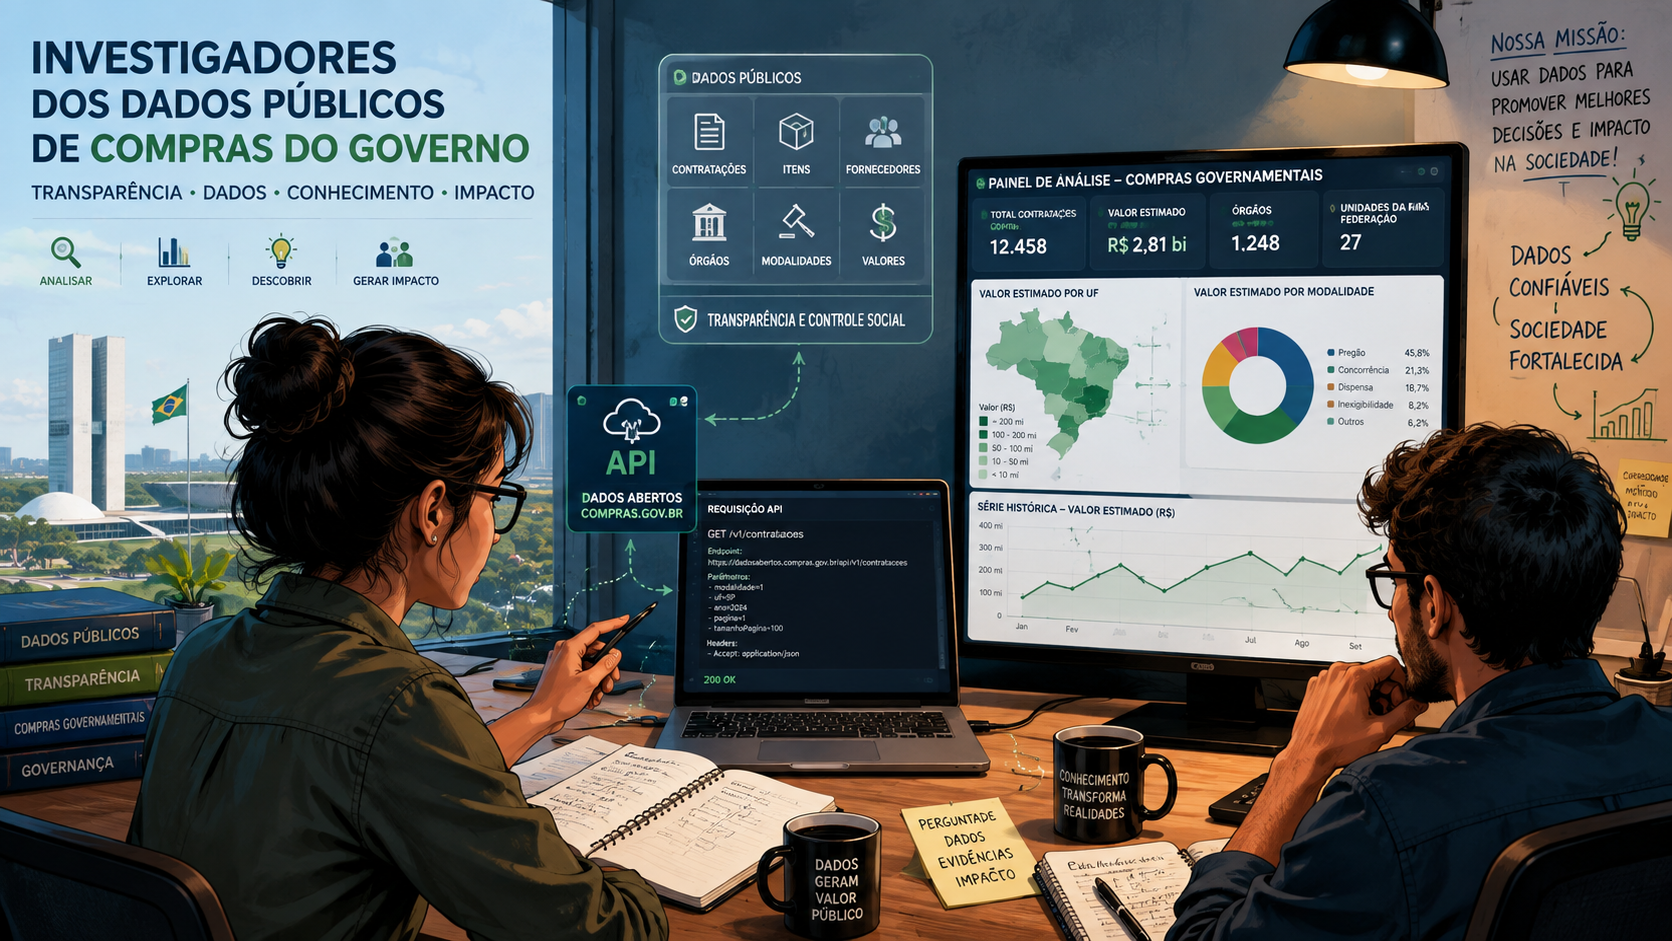
# Desafio em duplas: 


Cada dupla deverá escolher **um dos desafios** abaixo.

O objetivo não é apenas produzir gráficos. A dupla deverá transformar o tema escolhido em uma **investigação estruturada**, documentando:

1. pergunta de pesquisa;
2. justificativa;
3. hipótese ou expectativa inicial;
4. período analisado;
5. filtros utilizados na API;
6. variáveis selecionadas;
7. critérios de limpeza dos dados;
8. análise descritiva;
9. pelo menos uma comparação quantitativa;
10. interpretação dos resultados;
11. limitações;
12. conclusão.

A coleta deve ser **reprodutível**: os parâmetros utilizados na API precisam estar registrados no notebook.


## Desafio A — Compras públicas e diferenças regionais

### Problema

A distribuição das contratações públicas apresenta diferenças entre as Unidades da Federação?

### Possíveis perguntas

- A quantidade de contratações difere entre estados?
- Os valores das contratações apresentam distribuições diferentes?
- Existem estados com maior concentração de determinadas modalidades?

### Estratégia sugerida

Escolher de 3 a 5 UFs, manter o mesmo período e a mesma modalidade e comparar os resultados.

### Possíveis análises

- frequências;
- mediana e média;
- boxplots;
- coeficiente de variação;
- teste de Kruskal-Wallis ou ANOVA, quando os pressupostos forem adequados.


## Desafio B — Evolução temporal das contratações

### Problema

Existe variação temporal no volume ou no valor das contratações governamentais?

### Possíveis perguntas

- Determinados meses apresentam maior quantidade de contratações?
- Existe tendência de aumento ou redução ao longo do período?
- Há sazonalidade próxima ao final do exercício?

### Estratégia sugerida

Coletar dados de vários meses utilizando janelas temporais equivalentes.

### Possíveis análises

- série temporal;
- agregação mensal;
- média móvel;
- comparação entre meses;
- tendência linear exploratória.


## Desafio C — Modalidades de contratação

### Problema

As características das compras diferem entre modalidades de contratação?

### Possíveis perguntas

- Os valores estimados diferem entre modalidades?
- Algumas modalidades apresentam maior frequência em determinados órgãos?
- Existe associação entre modalidade e utilização de Sistema de Registro de Preços?

### Possíveis análises

- tabelas de contingência;
- proporções;
- teste qui-quadrado;
- comparação de distribuições de valores.


## Desafio D — Sistema de Registro de Preços

### Problema

Quais características diferenciam contratações realizadas com e sem Sistema de Registro de Preços?

### Possíveis perguntas

- O SRP é mais frequente em determinados tipos de contratação?
- Existem diferenças nos valores das contratações?
- Determinados órgãos utilizam SRP proporcionalmente mais do que outros?

### Variável de interesse

Quando disponível:

```text
srp
```

### Possíveis análises

- proporções;
- tabelas cruzadas;
- comparação de valores;
- teste qui-quadrado.


## Desafio E — Concentração das compras por órgão

### Problema

As contratações estão distribuídas entre muitos órgãos ou concentradas em poucos compradores?

### Possíveis perguntas

- Quais órgãos concentram maior quantidade de contratações?
- Qual percentual das compras está associado aos dez principais órgãos?
- A concentração muda entre períodos?

### Possíveis análises

- ranking;
- participação percentual;
- curva de Pareto;
- índice de concentração;
- comparação temporal.


## Desafio F — Análise textual dos objetos das contratações

### Problema

Quais temas aparecem com maior frequência nas descrições dos objetos das compras governamentais?

### Campo de interesse

Quando disponível:

```text
objetoCompra
```

### Possíveis análises

- frequência de palavras;
- bigramas;
- categorias definidas pela dupla;
- comparação entre órgãos ou períodos;
- identificação de temas recorrentes.

> O tratamento textual deve documentar remoção de pontuação, normalização, stopwords e demais decisões de pré-processamento.


## Desafio G — Dispersão de preços de um mesmo material

### Problema

Um mesmo material apresenta diferenças relevantes de preço nas compras governamentais?

### Estratégia

1. escolher um item no catálogo CATMAT;
2. identificar seu código;
3. utilizar o módulo de Pesquisa de Preços;
4. coletar compras comparáveis;
5. analisar a distribuição dos preços unitários.

### Possíveis perguntas

- O preço varia entre estados?
- Existem valores extremos?
- O preço apresenta relação com a quantidade comprada?
- Há diferença de preço entre períodos?

### Possíveis análises

- média;
- mediana;
- desvio padrão;
- intervalo interquartil;
- boxplot;
- correlação entre quantidade e preço;
- regressão exploratória.


## Desafio H — Fornecedores e concentração de mercado

### Problema

As compras de determinado item ou conjunto de contratações estão concentradas em poucos fornecedores?

### Estratégia

Utilizar os módulos de resultados de itens, fornecedores ou pesquisa de preços, conforme os campos disponíveis.

### Possíveis perguntas

- Quantos fornecedores participam do conjunto analisado?
- Qual a participação dos principais fornecedores?
- Existe concentração elevada?

### Possíveis análises

- ranking de fornecedores;
- participação percentual;
- curva de Pareto;
- índice Herfindahl-Hirschman (HHI), quando houver uma variável adequada de participação.

> A dupla deverá verificar na documentação quais endpoints fornecem as informações necessárias antes de definir definitivamente o desenho do estudo.


# Critérios para escolha do desafio

Antes de iniciar a coleta completa, a dupla deverá executar uma **consulta piloto**.

A consulta piloto deve responder:

- o endpoint está disponível?
- os campos necessários estão presentes?
- existe quantidade suficiente de registros?
- há muitos valores ausentes?
- a unidade de análise está clara?
- é possível reproduzir a consulta?

Somente depois dessa verificação a coleta principal deve ser realizada.


# Estrutura mínima do notebook da dupla

O notebook entregue deverá possuir:

```text
1. Título provisório
2. Problema de pesquisa
3. Pergunta de pesquisa
4. Hipótese
5. Fonte dos dados
6. Endpoint(s) utilizado(s)
7. Parâmetros da API
8. Período analisado
9. Código de coleta
10. Construção do DataFrame
11. Avaliação da qualidade dos dados
12. Limpeza
13. Estatística descritiva
14. Visualizações
15. Comparação quantitativa
16. Discussão
17. Limitações
18. Conclusão
```


# Proposta de estrutura para o artigo científico

A análise desenvolvida poderá ser transformada em um artigo curto.

## Título

Deve comunicar claramente:

```text
fenômeno + população/contexto + abordagem
```

## Introdução

Apresentar:

- contexto das compras públicas;
- problema;
- relevância;
- lacuna ou questão investigada;
- objetivo do estudo.

## Metodologia

Descrever:

- fonte dos dados;
- API e endpoints;
- data da coleta;
- período analisado;
- filtros;
- critérios de inclusão e exclusão;
- tratamento dos dados;
- métodos estatísticos.

## Resultados

Apresentar:

- tamanho da amostra;
- estatísticas descritivas;
- tabelas;
- gráficos;
- comparações.

## Discussão

Interpretar os resultados e relacioná-los ao problema proposto.

## Limitações

Discutir, por exemplo:

- cobertura da API;
- dados ausentes;
- alterações na base;
- duplicidades;
- diferenças de cadastramento;
- impossibilidade de inferir causalidade em estudos observacionais.

## Conclusão

Responder diretamente à pergunta de pesquisa.


# Checklist metodológico

Antes de considerar a análise concluída, verifique:

- [ ] A pergunta de pesquisa está claramente definida?
- [ ] O endpoint utilizado está registrado?
- [ ] Todos os parâmetros da API foram documentados?
- [ ] A data da coleta foi registrada?
- [ ] A unidade de análise está definida?
- [ ] Foram verificadas duplicidades?
- [ ] Foram avaliados valores ausentes?
- [ ] Variáveis numéricas foram convertidas corretamente?
- [ ] Datas foram convertidas para `datetime`?
- [ ] Valores extremos foram investigados?
- [ ] As comparações possuem justificativa?
- [ ] As conclusões são compatíveis com os dados?
- [ ] As limitações foram explicitadas?


# Cuidados com interpretação

Dados administrativos são produzidos para apoiar processos operacionais e administrativos. Eles não são originalmente coletados como um experimento científico.

Portanto:

```text
associação ≠ causalidade
```

Encontrar diferença de preços entre estados, por exemplo, não permite concluir automaticamente que a localização **causou** essa diferença.

Outros fatores podem estar envolvidos:

- quantidade adquirida;
- especificação do item;
- logística;
- fornecedor;
- período;
- modalidade;
- urgência;
- características do órgão.

Esses fatores devem ser considerados na interpretação.


# Boas práticas no consumo da API

Durante o projeto:

- evite realizar centenas de requisições desnecessárias;
- utilize filtros temporais;
- use paginação controlada;
- salve localmente os dados coletados para não consultar repetidamente a API;
- registre a data da coleta;
- preserve uma cópia dos dados brutos utilizados no estudo;
- não trate ausência de resposta da API como ausência real de contratações;
- valide resultados inesperados antes de interpretá-los.

Uma boa prática é separar:

```text
coleta → dados brutos → tratamento → dados analisados
```
